In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Reproducible random number generator
rng = np.random.default_rng(2026)

N = 10_000

transitions = {
    "U": [("I", 1/2), ("M", 1/2)],
    "I": [("U", 1/4), ("N", 1/2), ("A", 1/4)],
    "M": [("U", 3/4), ("A", 1/4)],
    "N": [("N", 3/4), ("Np", 1/4)],
    "Np": [("N", 1/2), ("Np", 1/2)]
}


def next_state(state):
    u = rng.random()
    cumulative = 0.0

    for new_state, probability in transitions[state]:
        cumulative += probability

        if u < cumulative:
            return new_state


def simulate(start, N=10_000):

    times = []
    outcomes = []

    for _ in range(N):

        state = start
        t = 0

        # Continue until absorption
        while state not in ["N", "Np", "A"]:
            state = next_state(state)
            t += 1

        times.append(t)

        if state in ["N", "Np"]:
            outcomes.append("fold")
        else:
            outcomes.append("aggregate")

    times = np.array(times)
    outcomes = np.array(outcomes)

    h_hat = np.mean(outcomes == "fold")

    g_hat = np.mean(times)

    tau_F_hat = np.mean(times[outcomes == "fold"])
    tau_A_hat = np.mean(times[outcomes == "aggregate"])

    return h_hat, g_hat, tau_F_hat, tau_A_hat, times, outcomes


# Run simulations from U, I, and M
results = {}

for start in ["U", "I", "M"]:

    results[start] = simulate(start, N)

    h_hat, g_hat, tau_F_hat, tau_A_hat, _, _ = results[start]

    print(f"Start = {start}")
    print(f"  h_hat       = {h_hat:.6f}")
    print(f"  g_hat       = {g_hat:.6f}")
    print(f"  tau_F_hat   = {tau_F_hat:.6f}")
    print(f"  tau_A_hat   = {tau_A_hat:.6f}")
    print()

Start = U
  h_hat       = 0.510800
  g_hat       = 4.011800
  tau_F_hat   = 4.062255
  tau_A_hat   = 3.959117

Start = I
  h_hat       = 0.624000
  g_hat       = 2.028600
  tau_F_hat   = 1.828526
  tau_A_hat   = 2.360638

Start = M
  h_hat       = 0.380900
  g_hat       = 4.046400
  tau_F_hat   = 5.032029
  tau_A_hat   = 3.439994



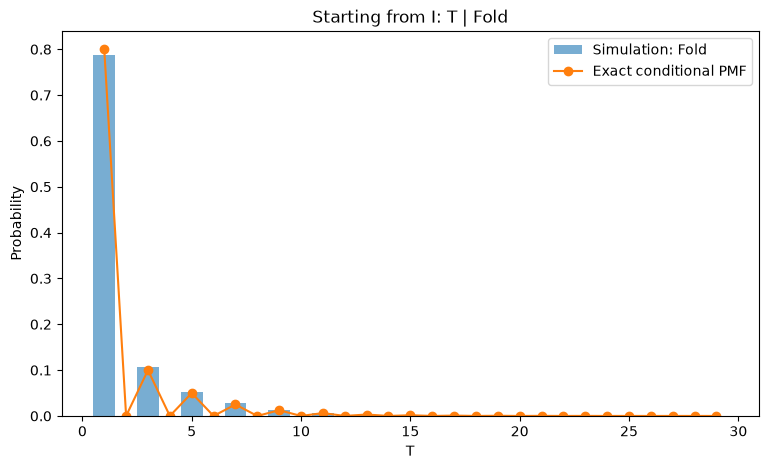

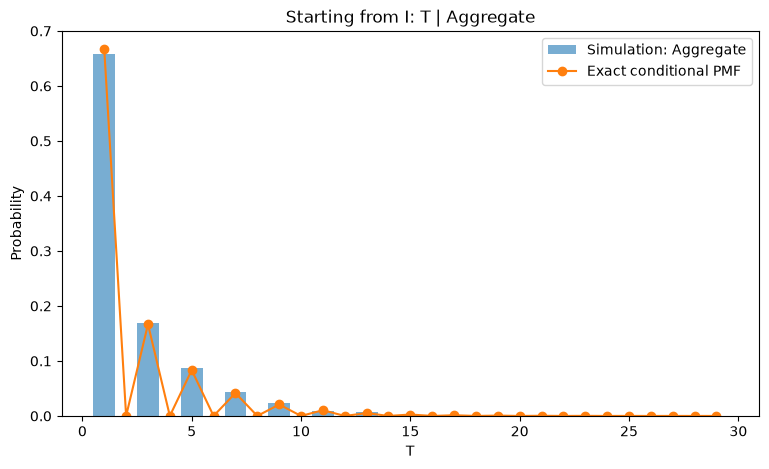

In [12]:
# Get simulation data for starting state I
_, _, _, _, times_I, outcomes_I = results["I"]

fold_times = times_I[outcomes_I == "fold"]
aggregate_times = times_I[outcomes_I == "aggregate"]

max_t = max(times_I)

n_values = np.arange(1, max_t + 1)

pmf_fold = np.zeros(max_t)
pmf_aggregate = np.zeros(max_t)

for n in n_values:

    if n % 2 == 1:

        if n == 1:
            pmf_fold[n - 1] = 4 / 5
            pmf_aggregate[n - 1] = 2 / 3

        else:
            k = (n - 1) // 2

            pmf_fold[n - 1] = 1 / (5 * 2**k)
            pmf_aggregate[n - 1] = 1 / (3 * 2**k)


# Folded runs

plt.figure(figsize=(9, 5))

bins = np.arange(0.5, max_t + 1.5, 1)

plt.hist(
    fold_times,
    bins=bins,
    weights=np.ones(len(fold_times)) / len(fold_times),
    alpha=0.6,
    label="Simulation: Fold"
)

plt.plot(
    n_values,
    pmf_fold,
    "o-",
    label="Exact conditional PMF"
)

plt.xlabel("T")
plt.ylabel("Probability")
plt.title("Starting from I: T | Fold")
plt.legend()
plt.savefig(os.path.expanduser("~/Downloads/HW4 P4 1.pdf"), bbox_inches="tight")

plt.show()


# Aggregated runs

plt.figure(figsize=(9, 5))

plt.hist(
    aggregate_times,
    bins=bins,
    weights=np.ones(len(aggregate_times)) / len(aggregate_times),
    alpha=0.6,
    label="Simulation: Aggregate"
)

plt.plot(
    n_values,
    pmf_aggregate,
    "o-",
    label="Exact conditional PMF"
)

plt.xlabel("T")
plt.ylabel("Probability")
plt.title("Starting from I: T | Aggregate")
plt.legend()
plt.savefig(os.path.expanduser("~/Downloads/HW4 P4 2.pdf"), bbox_inches="tight")

plt.show()